In [1]:
!pip install torch torchvision matplotlib numpy kaggle

In [15]:
# Mount Drive to save outputs persistently (optional but recommended)
from google.colab import drive
drive.mount('/content/drive')

# All other packages are pre-installed in Colab
# Only need to verify torch is GPU-enabled:
import torch
print(torch.cuda.is_available())  # Should print True
# This line is already correct — just confirm it's there
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {DEVICE}")  # add this print for confirmation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
Training on: cuda


In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1, 1] for Tanh
])

dataset = datasets.FashionMNIST(root='./content/data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2,pin_memory=True)

In [21]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # Project and reshape noise
            nn.Linear(noise_dim, 256 * 7 * 7),
            nn.Unflatten(1, (256, 7, 7)),

            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Final conv to 1 channel
            nn.Conv2d(64, 1, kernel_size=3, padding=1),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14 -> 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7x7 -> 3x3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def weights_init(m):
    """Initialize weights from Normal(0, 0.02) as per DCGAN paper"""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
# from model import Generator, Discriminator, weights_init
import os

# Hyperparameters (from original DCGAN paper)
NOISE_DIM  = 100
BETA1      = 0.5       # Adam momentum — important for stability
BATCH_SIZE = 128
EPOCHS     = 50
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# AFTER — save to Drive so files survive session restarts
os.makedirs('/content/drive/MyDrive/dcgan_outputs', exist_ok=True)
os.makedirs('/content/drive/MyDrive/dcgan_checkpoints', exist_ok=True)

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset    = datasets.FashionMNIST('./content/data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Models
G = Generator(NOISE_DIM).to(DEVICE)
D = Discriminator().to(DEVICE)
G.apply(weights_init)
D.apply(weights_init)

criterion  = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(BETA1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(BETA1, 0.999))

fixed_noise = torch.randn(64, NOISE_DIM, device=DEVICE)  # for visualization

G_losses, D_losses = [], []

for epoch in range(EPOCHS):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(DEVICE)
        b = real_imgs.size(0)

        real_labels = torch.ones(b, 1, device=DEVICE)
        fake_labels = torch.zeros(b, 1, device=DEVICE)

        # --- Train Discriminator ---
        opt_D.zero_grad()
        d_real = D(real_imgs)
        loss_d_real = criterion(d_real, real_labels)

        z = torch.randn(b, NOISE_DIM, device=DEVICE)
        fake_imgs = G(z).detach()  # detach: don't backprop through G
        d_fake = D(fake_imgs)
        loss_d_fake = criterion(d_fake, fake_labels)

        loss_D = loss_d_real + loss_d_fake
        loss_D.backward()
        opt_D.step()

        # --- Train Generator ---
        opt_G.zero_grad()
        z = torch.randn(b, NOISE_DIM, device=DEVICE)
        fake_imgs = G(z)
        d_fake = D(fake_imgs)
        loss_G = criterion(d_fake, real_labels)  # G wants D to say "real"
        loss_G.backward()
        opt_G.step()
        #second pass
        opt_G.zero_grad()
        z = torch.randn(b, NOISE_DIM, device=DEVICE)
        fake_imgs = G(z)
        loss_G2 = criterion(D(fake_imgs), real_labels)
        loss_G2.backward()
        opt_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    # Save sample images every epoch
    with torch.no_grad():
        samples = G(fixed_noise)
        save_image(samples, f'/content/drive/MyDrive/dcgan_outputs/epoch_{epoch+1:03d}.png',
                   nrow=8, normalize=True)

    print(f"Epoch {epoch+1}/{EPOCHS} | D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f}")

    # Save checkpoints every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(G.state_dict(), f'/content/drive/MyDrive/dcgan_checkpoints/G_epoch{epoch+1}.pth')
        torch.save(D.state_dict(), f'/content/drive/MyDrive/dcgan_checkpoints/D_epoch{epoch+1}.pth')

Epoch 1/50 | D loss: 1.4317 | G loss: 0.8322
Epoch 2/50 | D loss: 1.3704 | G loss: 0.7639
Epoch 3/50 | D loss: 1.3281 | G loss: 0.8448
Epoch 4/50 | D loss: 1.3372 | G loss: 0.7319
Epoch 5/50 | D loss: 1.3991 | G loss: 0.7041
Epoch 6/50 | D loss: 1.3612 | G loss: 0.7427
Epoch 7/50 | D loss: 1.3361 | G loss: 0.7915
Epoch 8/50 | D loss: 1.3593 | G loss: 0.7993
Epoch 9/50 | D loss: 1.3219 | G loss: 0.7351
Epoch 10/50 | D loss: 1.3534 | G loss: 0.7609
Epoch 11/50 | D loss: 1.3792 | G loss: 0.7553
Epoch 12/50 | D loss: 1.3356 | G loss: 0.7573
Epoch 13/50 | D loss: 1.3583 | G loss: 0.7422
Epoch 14/50 | D loss: 1.3533 | G loss: 0.7581
Epoch 15/50 | D loss: 1.3110 | G loss: 0.8090
Epoch 16/50 | D loss: 1.3246 | G loss: 0.7286
Epoch 17/50 | D loss: 1.3479 | G loss: 0.7910
Epoch 18/50 | D loss: 1.2935 | G loss: 0.8366
Epoch 19/50 | D loss: 1.3952 | G loss: 0.8133
Epoch 20/50 | D loss: 1.2465 | G loss: 0.9099
Epoch 21/50 | D loss: 1.2329 | G loss: 0.7303
Epoch 22/50 | D loss: 1.3270 | G loss: 0.68

In [29]:
import matplotlib.pyplot as plt
import torch

def plot_losses(G_losses, D_losses):
    plt.figure(figsize=(10, 4))
    plt.plot(G_losses, label='Generator Loss', alpha=0.7)
    plt.plot(D_losses, label='Discriminator Loss', alpha=0.7)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('DCGAN Training Losses — Fashion MNIST')
    plt.legend()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/dcgan_outputs/loss_curve.png', dpi=150)
    plt.show()

def generate_grid(generator, noise_dim=100, n=64, device='cpu'):
    from torchvision.utils import make_grid
    import numpy as np
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, noise_dim, device=device)
        imgs = generator(z)
        grid = make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title('Generated Fashion Items')
    plt.savefig('/content/drive/MyDrive/dcgan_outputs/final_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

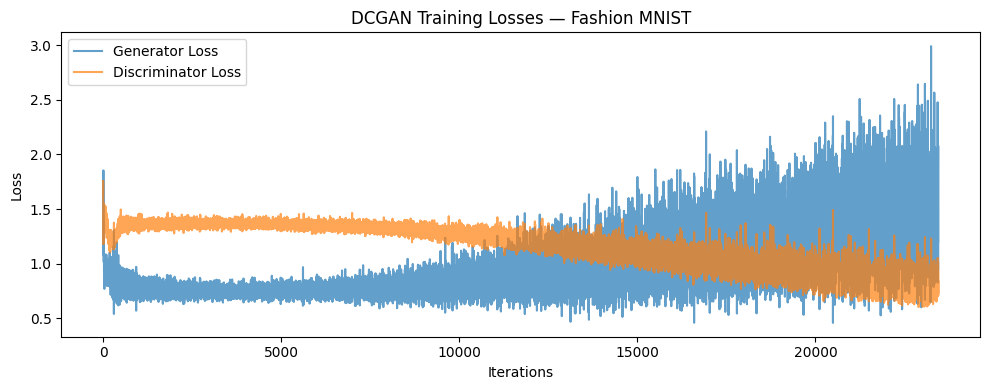

In [30]:
plot_losses(G_losses, D_losses)

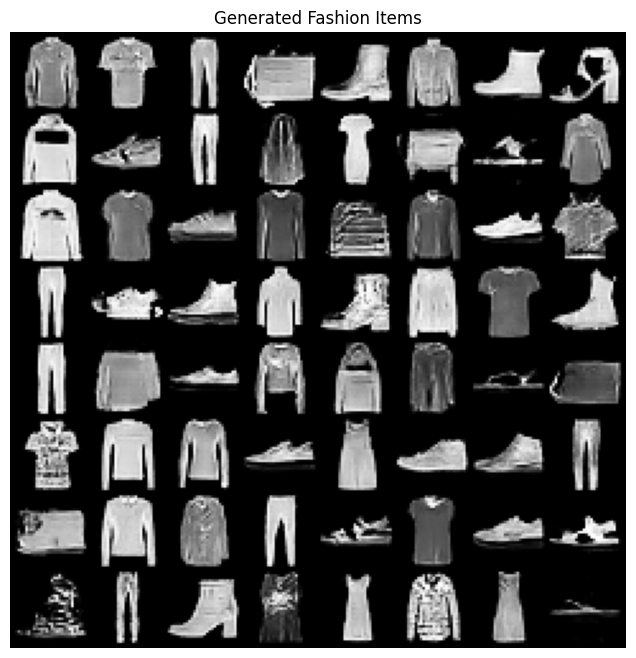

In [31]:
generate_grid(G, noise_dim=NOISE_DIM, n=64, device=DEVICE)

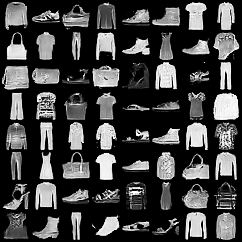

In [32]:
# Add this after save_image() calls to see results directly in the notebook
from IPython.display import display, Image
display(Image(f'/content/drive/MyDrive/dcgan_outputs/epoch_{epoch+1:03d}.png'))